### MULTIPLE LINEAR REGRESSION

#### Assignment Task:
- Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes

#### Tasks:
- 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import  warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head(10)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
5,12950,32,61000,Diesel,90,0,2000,3,4,5,1170
6,16900,27,94612,Diesel,90,0,2000,3,4,5,1245
7,18600,30,75889,Diesel,90,0,2000,3,4,5,1245
8,21500,27,19700,Petrol,192,0,1800,3,4,5,1185
9,12950,23,71138,Diesel,69,0,1900,3,4,5,1105


In [3]:
df.shape

(1436, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
cc,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0
Cylinders,1436.0,4.000000,0.000000,4.0,4.0,4.0,4.00,4.0
Gears,1436.0,5.026462,0.188510,3.0,5.0,5.0,5.00,6.0
Weight,1436.0,1072.459610,52.641120,1000.0,1040.0,1070.0,1085.00,1615.0


In [6]:
stats = pd.DataFrame({
    'Mean' : df.mean(numeric_only=True),
    'Median' : df.median(numeric_only=True),
    'Mode' : df.mode(numeric_only=True).iloc[0],
    'Standard Deviation' : df.std(numeric_only=True),
    '25%' : df.quantile(0.25,numeric_only=True),
    '50%' : df.quantile(0.50,numeric_only=True),
    '75' : df.quantile(0.75,numeric_only=True),
    'IQR' : df.quantile(0.75,numeric_only=True) - df.quantile(0.25,numeric_only=True)
})
stats

,Mean,Median,Mode,Standard Deviation,25%,50%,75,IQR
Price,10730.824513,9900.0,8950,3626.964585,8450.0,9900.0,11950.00,3500.00
Age_08_04,55.947075,61.0,68,18.599988,44.0,61.0,70.00,26.00
KM,68533.259749,63389.5,36000,37506.448872,43000.0,63389.5,87020.75,44020.75
HP,101.502089,110.0,110,14.981080,90.0,110.0,110.00,20.00
Automatic,0.055710,0.0,0,0.229441,0.0,0.0,0.00,0.00
cc,1576.855850,1600.0,1600,424.386770,1400.0,1600.0,1600.00,200.00
Doors,4.033426,4.0,5,0.952677,3.0,4.0,5.00,2.00
Cylinders,4.000000,4.0,4,0.000000,4.0,4.0,4.00,0.00
Gears,5.026462,5.0,5,0.188510,5.0,5.0,5.00,0.00
Weight,1072.459610,1070.0,1075,52.641120,1040.0,1070.0,1085.00,45.00


In [7]:
df.duplicated().sum()

1

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1435.0,10720.915679,3608.732978,4350.0,8450.0,9900.0,11950.0,32500.0
Age_08_04,1435.0,55.980488,18.563312,1.0,44.0,61.0,70.0,80.0
KM,1435.0,68571.782578,37491.094553,1.0,43000.0,63451.0,87041.5,243000.0
HP,1435.0,101.491986,14.981408,69.0,90.0,110.0,110.0,192.0
Automatic,1435.0,0.055749,0.229517,0.0,0.0,0.0,0.0,1.0
cc,1435.0,1576.560976,424.387533,1300.0,1400.0,1600.0,1600.0,16000.0
Doors,1435.0,4.032753,0.952667,2.0,3.0,4.0,5.0,5.0
Cylinders,1435.0,4.000000,0.000000,4.0,4.0,4.0,4.0,4.0
Gears,1435.0,5.026481,0.188575,3.0,5.0,5.0,5.0,6.0
Weight,1435.0,1072.287108,52.251882,1000.0,1040.0,1070.0,1085.0,1615.0


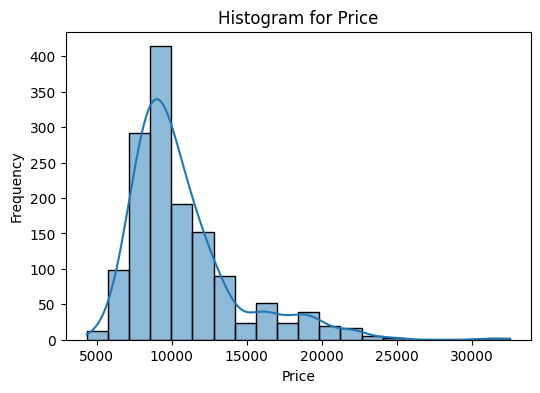

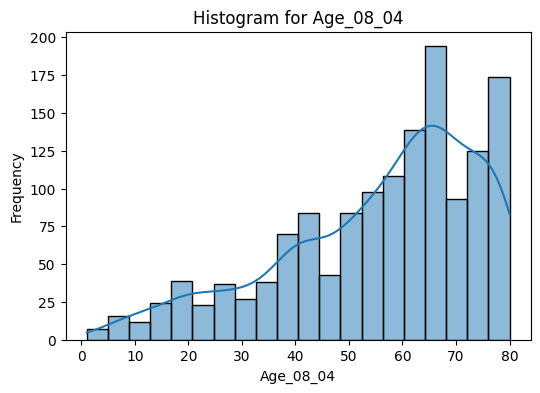

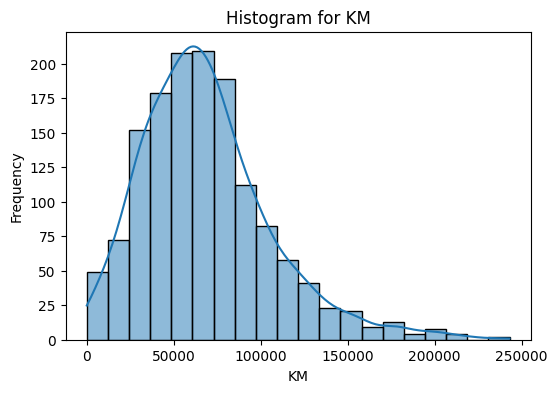

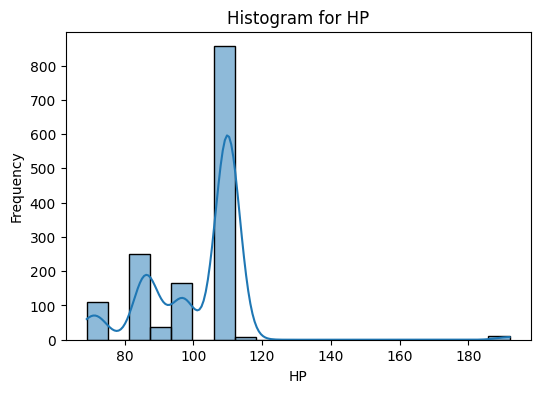

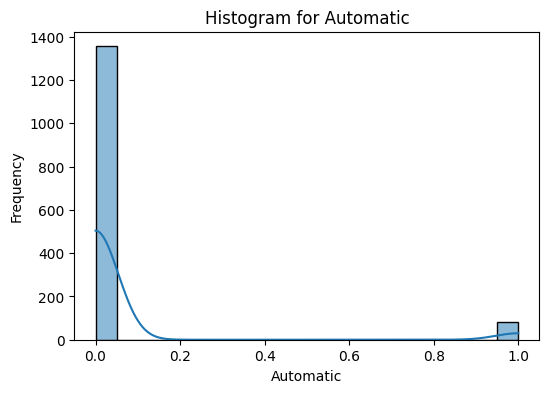

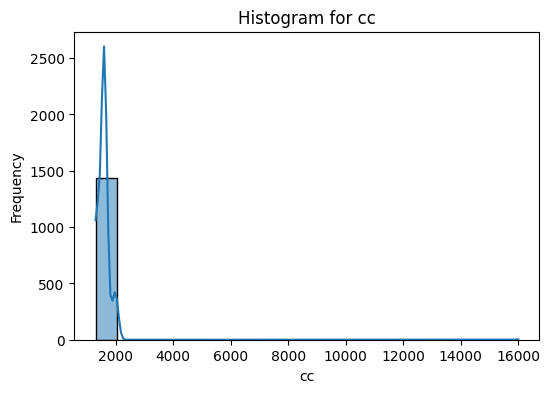

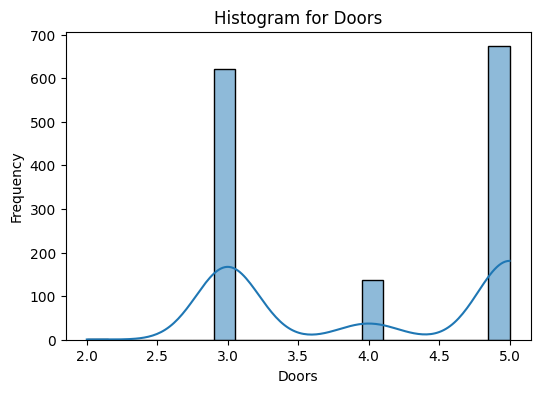

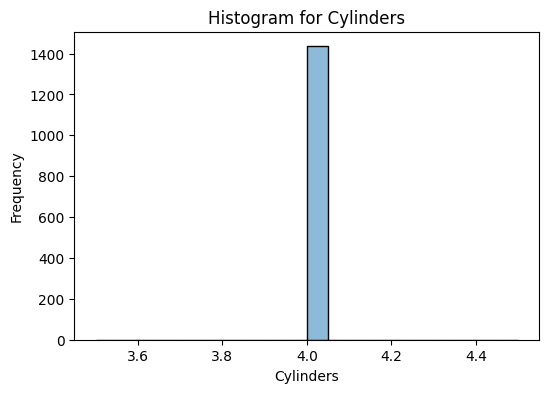

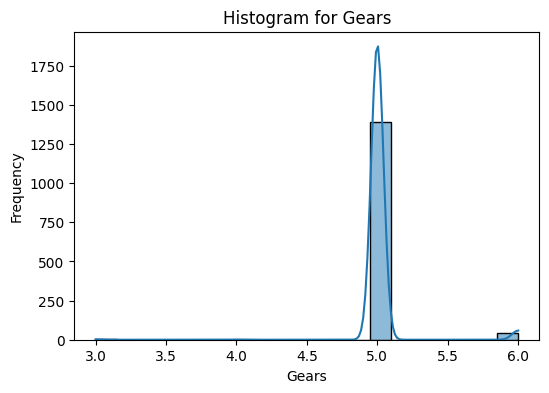

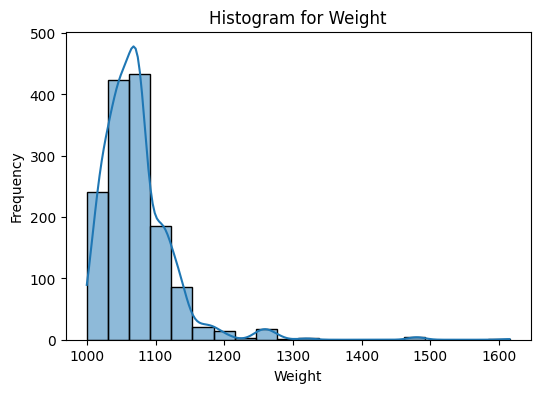

In [11]:
num_col = df.select_dtypes(include=np.number).columns
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=20,kde=True)
    plt.title(f"Histogram for {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#### 1. Histogram Analysis
##### Price
###### Observation:
- The distribution is positively (right) skewed.Most cars are priced between €8,000 and €12,000. A few expensive cars (above €20,000) create a long right tail.
###### Inference:
- Most Toyota Corolla cars are sold in the mid-price range, while only a few premium-priced cars are present.

##### Age_08_04

###### Observation:
- Most cars are between 50 and 80 months old. Very few cars are brand new.
###### Inference:
- The dataset mainly consists of older used cars, which is expected in the resale market.

##### KM
    
###### Observation:
- Right-skewed distribution. Most cars have travelled 40,000–90,000 km. A few cars have very high mileage (>150,000 km).
###### Inference:
-Most vehicles have moderate mileage, while a small number of cars have exceptionally high usage.

##### HP
###### Observation:
- Most cars have 90–110 HP.cA few cars have high horsepower (around 190 HP).
###### Inference:
- Standard engine variants dominate the dataset, with only a few high-performance models.

##### Automatic
###### Observation:
- Most observations are 0 (Manual transmission). Very few cars are automatic.
###### Inference:
- Manual transmission cars are much more common than automatic cars in this dataset.
    
##### CC
###### Observation:
- Most engine capacities are concentrated around 1400–2000 cc. One extreme value around 16000 cc is present.
###### Inference:
- Most vehicles have standard engine capacities, with a few unusually large engine values.

##### Doors

###### Observation:
- Most cars have 3 or 5 doors.
####### Inference:
- Toyota Corolla models in the dataset are primarily available as 3-door and 5-door variants.

##### Cylinders
    
###### Observation:
- Every car has 4 cylinders.
###### Inference:
- Since the column has no variation, it does not contribute to prediction and can be removed.

##### Gears
    
###### Observation:
- Almost all cars have 5 gears.
###### Inference:
- The variable has very little variation and therefore contributes limited information.

##### Weight
###### Observation:
- Most cars weigh between 1000 and 1100 kg. A few heavier cars appear as outliers.
###### Inference:
- Most vehicles have similar weights, while a few heavier variants are present.

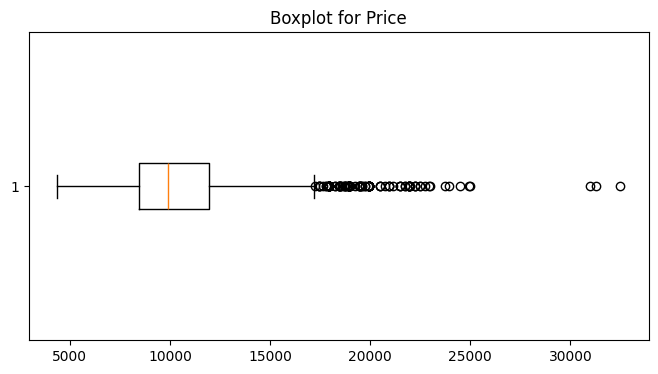

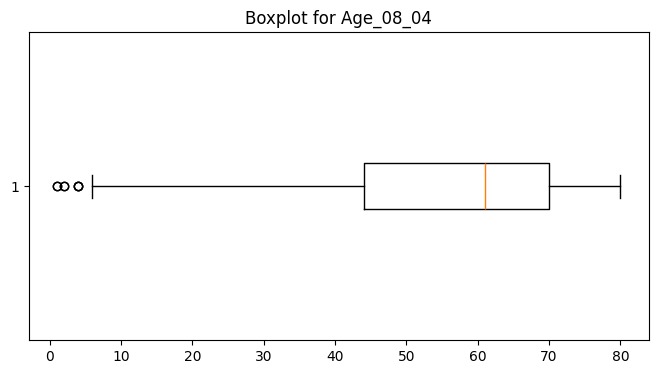

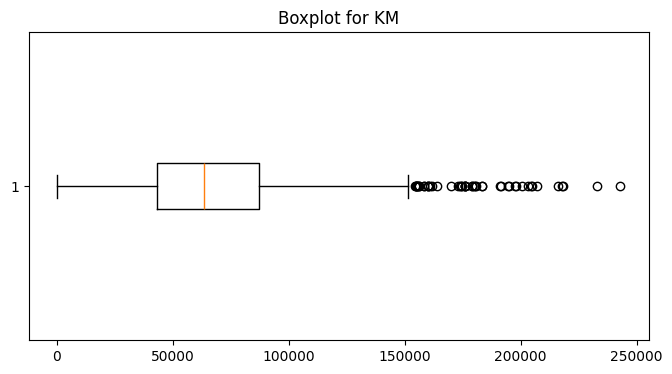

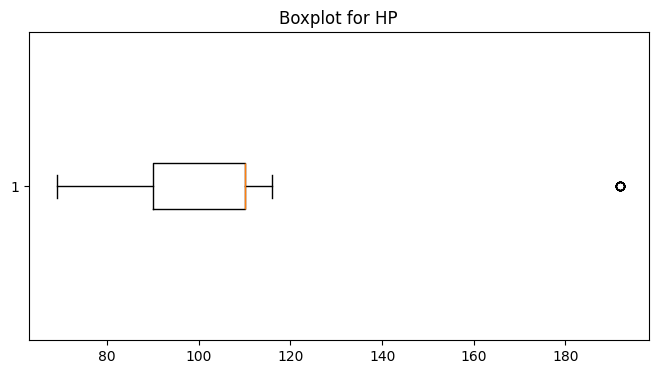

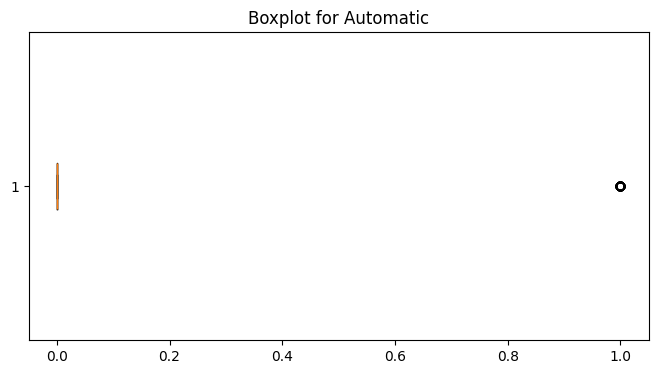

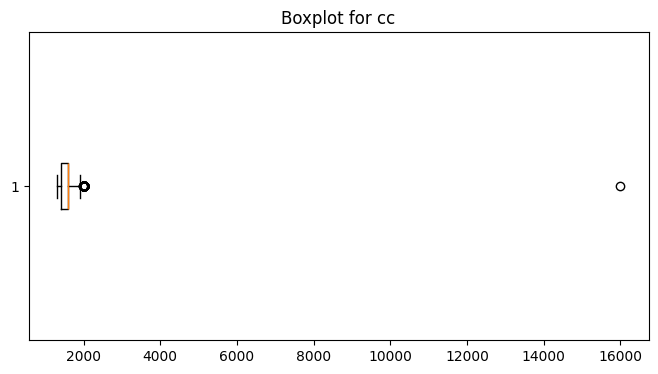

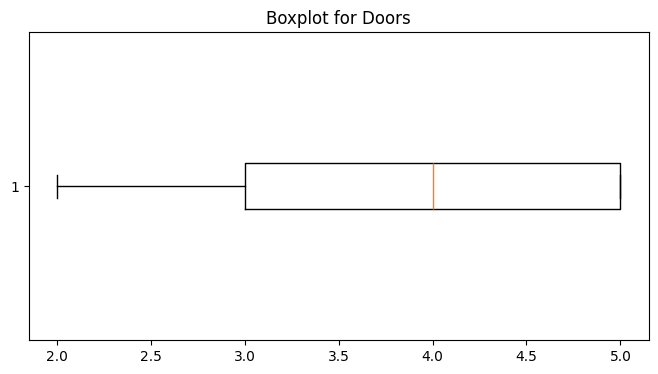

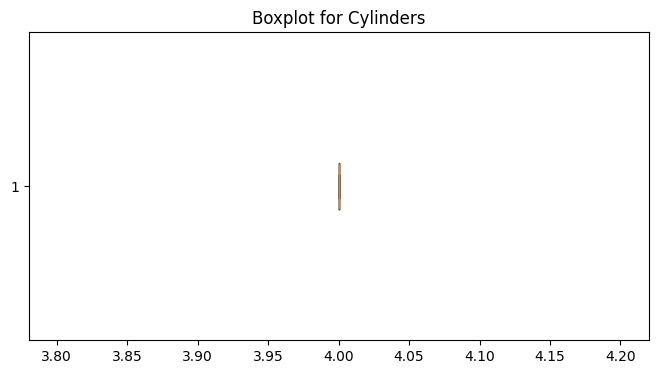

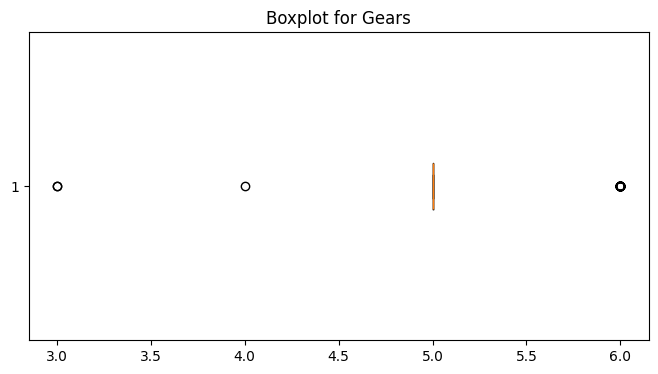

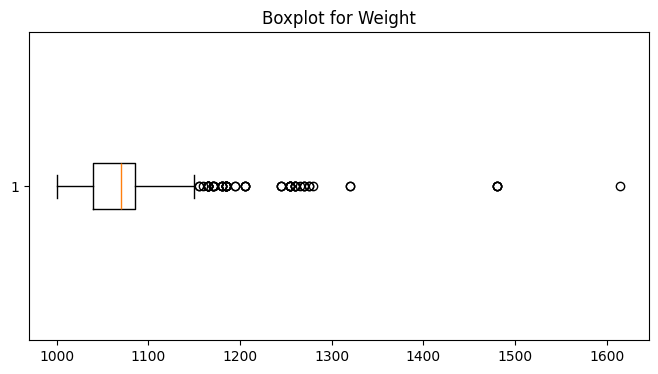

In [12]:
for col in num_col:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col],vert=False)
    plt.title(f"Boxplot for {col}")
    plt.show()

### 2. Boxplot Analysis
##### Price
###### Observation:
- Several high-price outliers are present.
###### Inference:
- A few expensive cars exist in the dataset, but these may represent genuine premium models rather than data errors.

##### Age_08_04
###### Observation:
- A few lower-age outliers are visible.
###### Inference:
- Some cars are much newer than the majority of vehicles.
    
##### KM
###### Observation:
- Many high-mileage outliers exist.
###### Inference:
These likely represent heavily used vehicles and are valid observations.
    
##### HP
###### Observation:
- One high-horsepower outlier is observed.
###### Inference:
- This corresponds to a high-performance Corolla variant.

##### Automatic

###### Observation:
- No meaningful boxplot interpretation because it is a binary variable.
###### Inference:
- Automatic is a categorical feature encoded as 0 and 1.

##### CC
###### Observation:
- Extreme engine capacity outlier is present.
###### Inference:
- One unusually large engine capacity is observed, while most vehicles fall within the normal range.

##### Doors
###### Observation:
- No significant outliers.
###### Inference:
- The number of doors is limited to a few discrete values (2–5).

##### Cylinders
###### Observation:
- No variation.
###### Inference:
- All vehicles have four cylinders; therefore, the feature was removed from further analysis.

##### Gears
###### Observation:
- Almost all observations are concentrated at 5 gears.
###### Inference:
- The feature has very low variability.

##### Weight
###### Observation:
- Several high-weight outliers exist.
###### Inference:
- Heavier vehicle variants are present but appear to be genuine observations.

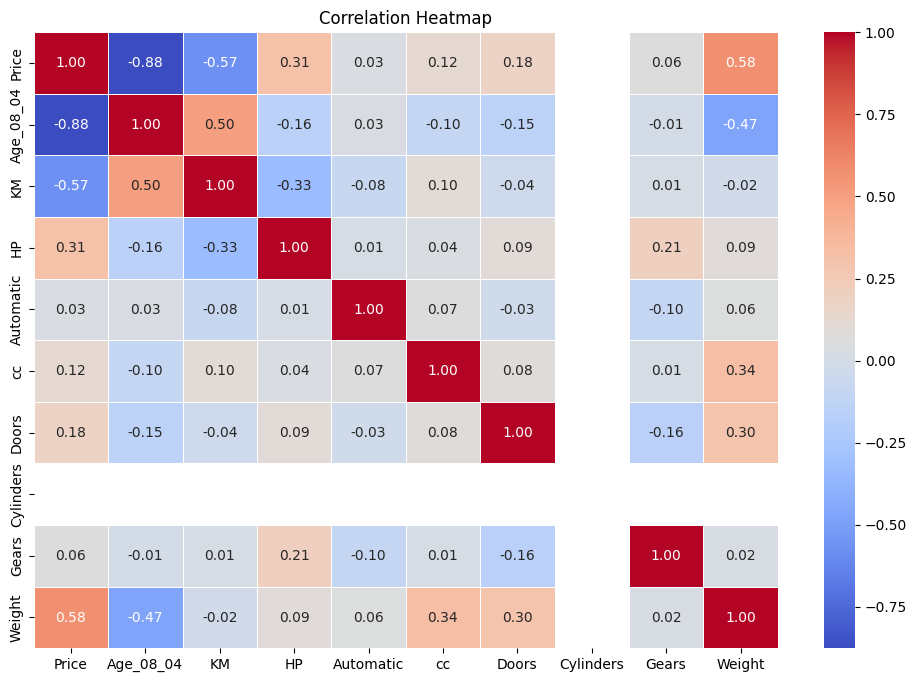

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### 3. Correlation Heatmap Analysis
##### Price vs Age_08_04 (-0.88)
###### Inference:
- There is a strong negative correlation between Age and Price, indicating that older cars tend to have lower selling prices.

##### Price vs KM (-0.57)
######Inference:
- Cars with higher mileage generally have lower resale prices.

##### Price vs Weight (0.58)
###### Inference:
- Heavier vehicles tend to have higher selling prices.

##### Price vs HP (0.31)
###### Inference:
- Horsepower has a moderate positive relationship with Price, suggesting that more powerful cars generally cost more.

##### Other Variables
###### Inference:
- Automatic transmission, Doors, CC, and Gears show relatively weak correlations with Price, indicating a smaller individual impact on the selling price.

###  Summary of EDA
- The exploratory data analysis revealed that most Toyota Corolla cars are older vehicles with moderate mileage and standard engine specifications. Price shows a strong negative correlation with Age and a moderate negative correlation with KM, while Weight and HP have positive relationships with Price. Several variables contain genuine outliers, but no missing values were found. Since the Cylinders feature has no variation, it was removed before model building. Overall, the dataset is suitable for Multiple Linear Regression after the necessary preprocessing steps.

In [14]:
df["Cylinders"].value_counts()

Cylinders
4    1435
Name: count, dtype: int64

In [15]:
df.drop("Cylinders", axis=1, inplace=True)

In [16]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type'],
    drop_first=True,
    dtype=int
)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


- 2. Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [17]:
X = df.drop('Price', axis=1)
y = df['Price']

In [18]:
vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]
vif

,Features,VIF
0,Age_08_04,17.124003
1,KM,8.668100
2,HP,96.878874
3,Automatic,1.149317
4,cc,18.112702
5,Doors,22.969257
6,Gears,531.195891
7,Weight,652.805792
8,Fuel_Type_Diesel,12.565234
9,Fuel_Type_Petrol,75.453528


### Model 1

In [19]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [20]:
model_1 = LinearRegression()
model_1.fit(X1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y1_pred = model_1.predict(X1_test)

In [22]:
coef_1 = pd.DataFrame({
    "Features" : X.columns,
    "Coefficient" : model_1.coef_
})
coef_1

,Features,Coefficient
0,Age_08_04,-121.229191
1,KM,-0.015997
2,HP,16.075438
3,Automatic,268.822211
4,cc,-0.047109
5,Doors,-88.097164
6,Gears,455.011874
7,Weight,26.361202
8,Fuel_Type_Diesel,-389.683843
9,Fuel_Type_Petrol,1128.933060


In [23]:
print("Intercept :", model_1.intercept_)

Intercept : -14115.237225945792


In [24]:
comparison1 = pd.DataFrame({
    "Actual Price": y1_test,
    "Predicted Price": y1_pred
})

comparison1.head(10)

,Actual Price,Predicted Price
753,9950,10807.905356
858,7995,10326.707030
630,7500,9168.774419
1412,9950,9347.156265
975,8950,8470.341325
800,8995,8543.655424
1030,9450,7890.514913
1372,6750,8267.185158
260,11950,11740.098252
317,10950,12334.336739


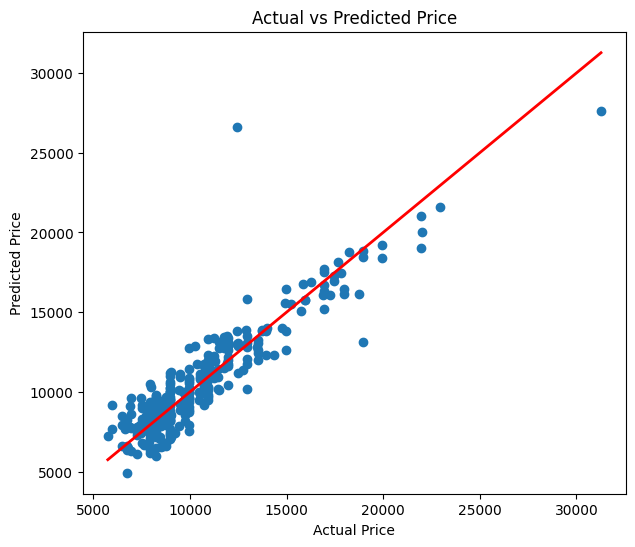

In [25]:
plt.figure(figsize=(7,6))
plt.scatter(y1_test, y1_pred)
plt.plot(
    [y1_test.min(), y1_test.max()],
    [y1_test.min(), y1_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

- 3. Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

### Model 2

In [26]:
X2 = df.drop([
        "Price",
        "Doors",
        "Gears"
],axis=1)

In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y,train_size=0.8,test_size=0.20,random_state=42)

In [28]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y2_pred = model2.predict(X2_test)

In [30]:
print("MAE :", mean_absolute_error(y2_test, y2_pred))
print("RMSE :", np.sqrt(mean_squared_error(y2_test, y2_pred)))
print("R2 :", r2_score(y2_test, y2_pred))

MAE : 987.0269288885448
RMSE : 1466.5473147737816
R2 : 0.8207270947062066


### Model 3

In [31]:
X3 = df[[
        "Age_08_04",
        "KM",
        "HP",
        "Weight"
]]

In [32]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y,
    train_size=0.8,
    test_size=0.20,
    random_state=42
)

In [33]:
model3 = LinearRegression()
model3.fit(X3_train, y3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y3_pred = model3.predict(X3_test)

In [35]:
print("MAE :", mean_absolute_error(y3_test, y3_pred))
print("RMSE :", np.sqrt(mean_squared_error(y3_test, y3_pred)))
print("R2 :", r2_score(y3_test, y3_pred))

MAE : 987.225283393743
RMSE : 1390.8554272038587
R2 : 0.8387549179514566


- 5.Apply Lasso and Ridge methods on the model.

In [36]:
scalar1 = StandardScaler()
X1_train_scaled = scalar1.fit_transform(X1_train)
X1_test_scaled = scalar1.transform(X1_test)

In [37]:
ridge = Ridge(alpha=1)
ridge.fit(X1_train_scaled, y1_train)
ridge_pred = ridge.predict(X1_test_scaled)

In [38]:
print("MAE :", mean_absolute_error(y1_test, ridge_pred))
print("RMSE :", np.sqrt(mean_squared_error(y1_test, ridge_pred)))
print("R2 :", r2_score(y1_test, ridge_pred))

MAE : 986.420137953595
RMSE : 1467.3206753839604
R2 : 0.8205379713720663


In [39]:
lasso = Lasso(alpha=0.5)
lasso.fit(X1_train_scaled, y1_train)
lasso_pred = lasso.predict(X1_test_scaled)

In [40]:
print("MAE :", mean_absolute_error(y1_test, lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(y1_test, lasso_pred)))
print("R2 :", r2_score(y1_test, lasso_pred))

MAE : 986.3339978374357
RMSE : 1467.506305905497
R2 : 0.8204925610704461


- Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [41]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression (All Features)",
        "Linear Regression (Reduced Features)",
        "Linear Regression (Important Features)",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R2 Score": [
        r2_score(y1_test, y1_pred),
        r2_score(y2_test, y2_pred),
        r2_score(y3_test, y3_pred),
        r2_score(y1_test, ridge_pred),
        r2_score(y1_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y1_test, y1_pred)),
        np.sqrt(mean_squared_error(y2_test, y2_pred)),
        np.sqrt(mean_squared_error(y3_test, y3_pred)),
        np.sqrt(mean_squared_error(y1_test, ridge_pred)),
        np.sqrt(mean_squared_error(y1_test, lasso_pred))
    ],
    "MAE": [
        mean_absolute_error(y1_test, y1_pred),
        mean_absolute_error(y2_test, y2_pred),
        mean_absolute_error(y3_test, y3_pred),
        mean_absolute_error(y1_test, ridge_pred),
        mean_absolute_error(y1_test, lasso_pred)
    ]
})
results

,Model,R2 Score,RMSE,MAE
0,Linear Regression (All Features),0.820321,1468.205829,986.496688
1,Linear Regression (Reduced Features),0.820727,1466.547315,987.026929
2,Linear Regression (Important Features),0.838755,1390.855427,987.225283
3,Ridge Regression,0.820538,1467.320675,986.420138
4,Lasso Regression,0.820493,1467.506306,986.333998


- Three Multiple Linear Regression models were developed to predict the selling price of Toyota Corolla cars. Model performance was evaluated using MAE, RMSE, and R² score. Among all models, the Important Features model (Age_08_04, KM, HP, and Weight) achieved the highest R² (0.8388) and the lowest RMSE (1390.86), indicating the best predictive performance. Ridge and Lasso regression produced similar performance to the full linear regression model but did not outperform Model 3. Therefore, Model 3 was selected as the final model.

### Interview Questions:

#### 1. What is Normalization & Standardization and how is it helpful?
- Normalization and Standardization are data preprocessing techniques used to bring numerical features to a similar scale before building a machine learning model. Normalization rescales the values to a fixed range, usually between 0 and 1, while Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. These techniques help prevent variables with larger values from dominating the model, improve model performance, and make training more stable. In this assignment, Standardization was used before applying Ridge and Lasso Regression because these algorithms are sensitive to the scale of the input features.

#### 2. What techniques can be used to address multicollinearity in Multiple Linear Regression?
- Multicollinearity occurs when two or more independent variables are highly correlated with each other, making it difficult for the model to identify the individual effect of each variable. It can be addressed by checking the Variance Inflation Factor (VIF), removing highly correlated variables, selecting only the most important features, or using regularization techniques such as Ridge Regression and Lasso Regression. In this assignment, multicollinearity was identified using VIF, and different regression models, along with Ridge and Lasso Regression, were used to reduce its effect and improve the model's performance.